Title: Customer Behavior Analysis & Business Decision Making

In [ ]:
import pandas as pd
import numpy as np

df=pd.read_csv("Mall_Customers.csv")

SECTION 1: Data understanding

In [ ]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
df.shape

(200, 5)

In [ ]:
#200 rows * 5 col

In [ ]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
# zero null values

In [ ]:
df.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


What type of dataset is this?
This is customer dataset.This indicates annual income and their spending in mall

Which features are numerical/categorical?
gender has object dtype mean it is only categorical feature and other all as numerical feature

SECTION 2: Descriptive Analysis

In [ ]:
#mean,median,std of age col
avg_age=df["Age"].mean()
med_age=df["Age"].median()
std_age=df["Age"].std()
print("Average age is: ",avg_age)
print("median is: ",med_age)
print("standard deviation is:",std_age)

Average age is:  38.85
median is:  36.0
standard deviation is: 13.969007331558883


In [ ]:
#mean,median,std of Annual Income col
avg_income=df["Annual Income (k$)"].mean()
med_income=df["Annual Income (k$)"].median()
std_income=df["Annual Income (k$)"].std()
print("Average income is: ",avg_income)
print("median income is: ",med_income)
print("standard deviation is:",std_income)

Average income is:  60.56
median is:  61.5
standard deviation is: 26.264721165271254


In [ ]:
#mean,median,std of standard deviation col
avg_spending=df["Spending Score (1-100)"].mean()
med_spending=df["Spending Score (1-100)"].median()
std_spending=df["Spending Score (1-100)"].std()
print("Average spending score is: ",avg_spending)
print("median spending score is: ",med_spending)
print("standard deviation is:",std_spending)

Average spending score is:  50.2
median spending score is:  50.0
standard deviation is: 25.823521668370162


In [ ]:
'''Which feature shows the highest variability?
Annual Income has the highest variability because its standard deviation
is the highest among all features.
'''

In [ ]:
'''Are customers similar or diverse?
Customers are diverse because their income and spending scores are not related.
The high standard deviation values indicate that customers belong to different
income groups and have different spending behaviors making the customer base
diverse than similar.
'''

SECTION 3: Visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


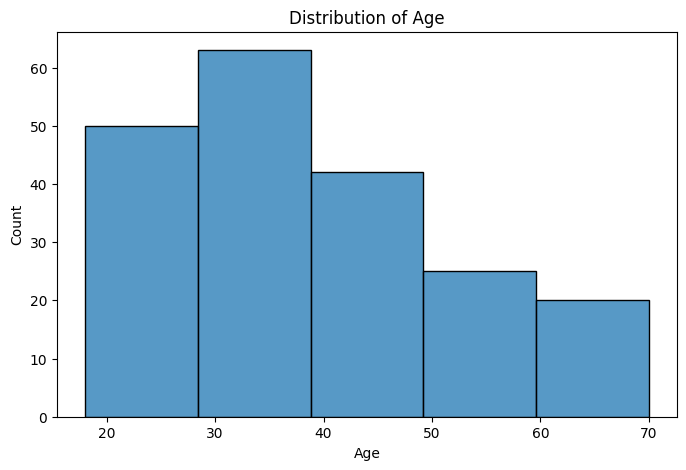

In [ ]:
#hist age
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=5)
plt.title("Distribution of Age")
plt.show()

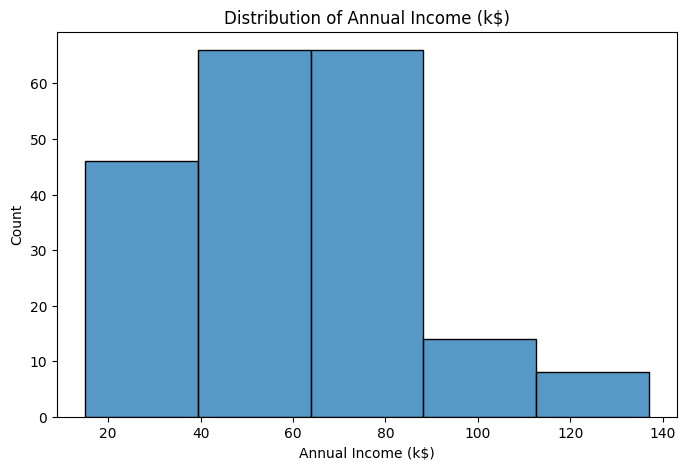

In [ ]:
#hist annual income
plt.figure(figsize=(8,5))
sns.histplot(df['Annual Income (k$)'], bins=5)
plt.title("Distribution of Annual Income (k$)")
plt.show()

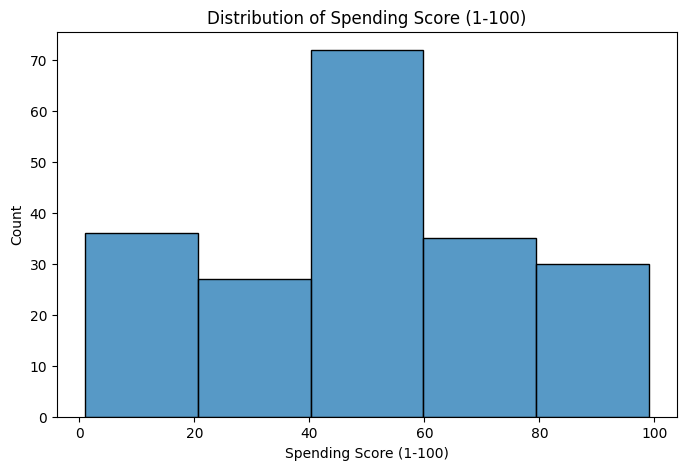

In [ ]:

#hist Spending score
plt.figure(figsize=(8,5))
sns.histplot(df['Spending Score (1-100)'], bins=5)
plt.title("Distribution of Spending Score (1-100)")
plt.show()

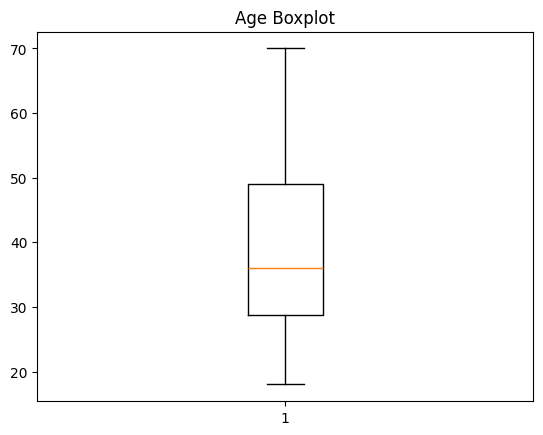

In [ ]:
# Age Boxplot
plt.boxplot(df['Age'])
plt.title("Age Boxplot")
plt.show()



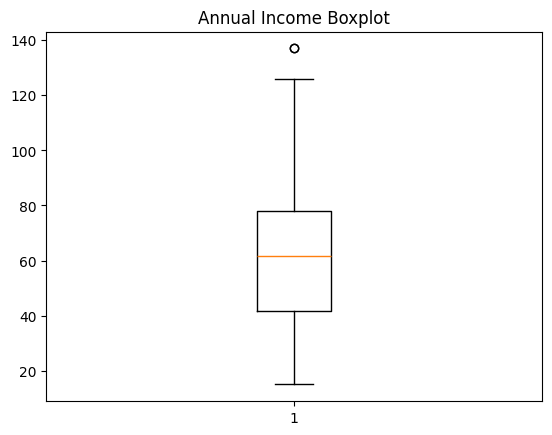

In [ ]:
# Income Boxplot
plt.boxplot(df['Annual Income (k$)'])
plt.title("Annual Income Boxplot")
plt.show()



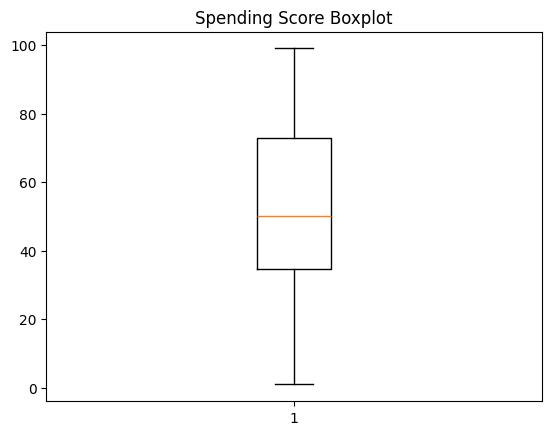

In [ ]:
# Spending Score Boxplot
plt.boxplot(df['Spending Score (1-100)'])
plt.title("Spending Score Boxplot")
plt.show()

SECTION 4: Group-Based Analysis

In [ ]:
df.groupby('Gender').mean()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Gender,,,,
Female,97.562500,38.098214,59.250000,51.526786
Male,104.238636,39.806818,62.227273,48.511364


In [ ]:
df["Annual Income (k$)"].mean()


np.float64(60.56)

In [ ]:
df["Spending Score (1-100)"].mean()

np.float64(50.2)

avgincome=60.56
avgspending=50.2


male :- income=62.227273
        spending=48.511364



female:- income=59.250000
          spending=51.526786



Which group spends more?
female(51.6) spends more than male(48.6)



Is there a visible difference?
Yes, male customer have higher income and lower spending than female


SECTION 5: Correlation Analysis




In [ ]:
# Correlation Matrix
df[['Age','Annual Income (k$)','Spending Score (1-100)']].corr()



,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


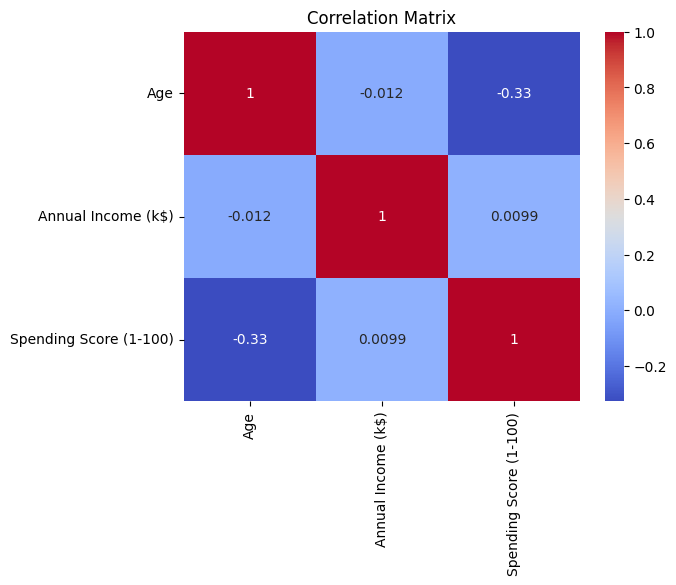

In [ ]:

sns.heatmap(
    df[['Age',
        'Annual Income (k$)',
        'Spending Score (1-100)']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

Do richer customers spend more?
There no exact corelation on that but, who earns more usally spends less
Does age affect spending?
Yes younger spends more

SECTION 7: Confidence Interval (95% CI for Spending Score)

A 95% Confidence Interval (CI) estimates the range in which the true average spending score of all mall customers is likely to lie.

In [ ]:
import scipy.stats as stats


spending = df['Spending Score (1-100)']

mean = spending.mean()
std = spending.std()
n = len(spending)

# 95% Confidence Interval
margin_error = stats.t.ppf(0.975, n-1) * (std / np.sqrt(n))

lower = mean - margin_error
upper = mean + margin_error

print("Mean Spending Score:", mean)
print("95% Confidence Interval:")
print(f"({lower:.2f}, {upper:.2f})")

Mean Spending Score: 50.2
95% Confidence Interval:
(46.60, 53.80)


What range do customers fall into?

We conclude that the true average spending score of mall customers lies between 46.60 and 53.80.

How confident are we?

We are 95% confident that the true population mean spending score falls within this interval.

**SECTION 8: Business Insights**

1. Which customers should the business target?


High Income + High Spending customers (Premium Customers)
Young customers with high spending scores


These groups are likely to generate the highest revenue.

2. Does income affect spending?

No.

The correlation between Annual Income and Spending Score is approximately 0.01, indicating almost no relationship.

A higher income does not necessarily mean higher spending.

3. Should marketing differ by gender?

Yes.

Female customers have a slightly higher average spending score.
Male customers have slightly higher average income.

Different promotions and product recommendations for more focus on female generate highest revenue

4. What strategy would you suggest?

Create premium programs for high-spending customers.
Offer personalized discounts to high-income, low-spending customers.
Target younger customers through social media.
Provide exclusive offers for premium customer groups (specially for female group).

FINAL DELIVERABLE
Key Findings
Dataset contains 200 customers and 5 features.
No missing values were found.
Female customers spend slightly more than male customers.
Income has almost no effect on spending behavior.
Younger customers tend to spend more than older customers.
The average spending score is approximately 50.20.




Statistical Conclusions
Annual Income and Spending Score are not significantly correlated.



Business Recommendations
Focus on high-spending customers and younger customers.
Develop separate marketing campaigns for different customer groups (specially for female group).
